# Chatbot with Memory
## Review
Memory is a cognitive function that allows people to store, retrieve, and use information to understand their present and future.

There are various long-term memory types that can be used in AI applications.

## Goals
Here, we'll introduce the LangGraph Memory Store as a way to save and retrieve long-term memories. We'll build a chatbot that uses both `short-term (within-thread)` and `long-term (across-thread)` memory.

We'll focus on long-term semantic memory, which will be facts about the user. These long-term memories will be used to create a personalized chatbot that can remember facts about the user.

## Introduce to the LangGraph Store
The LangGraph Memory Store provides a way to store and retrieve information across threads in LangGraph.

This is an open source base class for persistent `key-value` stores.

In [8]:
import os
import re 
import uuid
from dotenv import load_dotenv

from IPython.display import Image, display
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.store.base import BaseStore

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.runnables.config import RunnableConfig

# Load env variable for API Key
load_dotenv()
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = os.getenv("DEEPSEEK_BASE_URL")

# Set the Chat Model
model = ChatOpenAI(
    model="deepseek-v4-pro",  # Or "deepseek-v4-flash" for a faster option
    api_key=DEEPSEEK_API_KEY,
    base_url=DEEPSEEK_BASE_URL,
    temperature=0
)

When storing objects (memories) in the store, we provide:
- The `namespace` for the object, a tuple (similar to directories).
- The object `key` (similar to filename)
- The object `value` (similar to file contents)

We use the put method to save an object to the store by `namespace` and `key`.

In [9]:
in_memory_store = InMemoryStore()

# Namespace for the memory to save
user_id = "1"
namespace_for_memory = (user_id, "memories")

# Save a memory to namespace as key and value
key = str(uuid.uuid4())
value = {"food_preference": "I like pizza"}

# Save the memory
in_memory_store.put(namespace_for_memory, key, value)

# Search
memories = in_memory_store.search(namespace_for_memory)
type(memories)
print(memories[0].dict())

# Get the memory by namespace and key
memory = in_memory_store.get(namespace_for_memory, key)
print(memory.dict())

{'namespace': ['1', 'memories'], 'key': '4e0fd8ef-ca05-4348-bc93-a3836fc06c82', 'value': {'food_preference': 'I like pizza'}, 'created_at': '2026-07-22T00:24:56.402594+00:00', 'updated_at': '2026-07-22T00:24:56.402603+00:00', 'score': None}
{'namespace': ['1', 'memories'], 'key': '4e0fd8ef-ca05-4348-bc93-a3836fc06c82', 'value': {'food_preference': 'I like pizza'}, 'created_at': '2026-07-22T00:24:56.402594+00:00', 'updated_at': '2026-07-22T00:24:56.402603+00:00'}


## Chatbot with Long-term Memory
We want a chatbot that has two types of memory:
1. `Short-term (within-thread) memory`: Chatbot can persist conversational history and allow interruptions in a chat session.
2. `Long-term (cross-thread) memory`: Chatbot can remember information about a specific user across all chat sessions.

For `short-term memory`, we'll use a checkpointer. In summary:
- They write the graph state at each step to a thread.
- They persist the chat history in the thread.
- They allow the graph to be interrupted and resumed from any step in the thread.

For `long-term memory`, we'll use LangGraph Store as introduced above.

The chat history will be saved to short-term memory using the checkpointer. The chatbot will reflect on the chat history. It will then create and save a memory to the LangGraph Store. This memory is accessible in future chat sessions to personalize the chatbot's response.

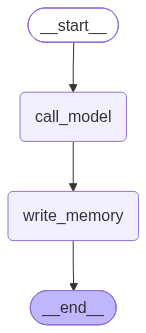

================================ Human Message =================================

Hi, my name is Lance.
================================== Ai Message ==================================

Hi Lance! It's nice to meet you. How can I assist you today?


In [10]:
# Chatbot instruction
MODEL_SYSTEM_MESSAGE = """
    You are a helpful assistant with memory that provides information about the user.
    If you have memory for this user, use it to personalize your responses. Here is the
    memory (it may be empty): {memory}.
"""

# Create new memory from the chat history and any existing memory
CREATE_MEMORY_INSTRUCTION = """
    You are collecting information about the user to personalize your responses.
    CURRENT USER INFORMATION: {memory}

    INSTRUCTIONS:
    1. Review the chat history below carefully.
    2. Identify new information about the user, such as:
        - Personal details (name, location)
        - Preferences (likes, dislikes)
        - Interests and hobbies
        - Past experiences
        - Goals or future plans
    3. Merge any new information with existing memory.
    4. Format the memory as a clear, bulleted list.
    5. If new information conflicts with existing memory, keep the most recent version.

    Remember: Only include factual information directly stated by the user. Do not make assumptions or inferences.
    Based on the chat history below, please update the user information:
"""

def call_model(state: MessagesState, config: RunnableConfig, store: BaseStore):
    """
    Load memory from the store and use it to personalize the chatbot's response.
    """
    user_id = config["configurable"]["user_id"]
    
    # Retrieve memory from the store
    namespace = ("memory", user_id)
    key = "user_memory"
    existing_memory = store.get(namespace, key)

    if existing_memory:
        existing_memory_content = existing_memory.value.get("memory")
    else:
        existing_memory_content = "No existing memory found."

    system_msg = MODEL_SYSTEM_MESSAGE.format(memory=existing_memory_content)
    response = model.invoke([SystemMessage(content=system_msg)] + state["messages"])
    return {"messages": response}

def write_memory(state: MessagesState, config: RunnableConfig, store: BaseStore):
    """
    Reflect on the chat history and save a memory to the store.
    """
    user_id = config["configurable"]["user_id"]
    
    # Retrieve memory from the store
    namespace = ("memory", user_id)
    key = "user_memory"
    existing_memory = store.get(namespace, key)
    
    if existing_memory:
        existing_memory_content = existing_memory.value.get("memory")
    else:
        existing_memory_content = "No existing memory found."

    system_msg = CREATE_MEMORY_INSTRUCTION.format(memory=existing_memory_content)
    new_memory = model.invoke([SystemMessage(content=system_msg)] + state["messages"])
    
    # Overwrite the existing memory in the store
    store.put(namespace, key, {"memory": new_memory.content})

# Build the graph
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_node("write_memory", write_memory)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", "write_memory")
builder.add_edge("write_memory", END)

# Store for long-term memory
across_thread_memory = InMemoryStore()

# Checkpointer for short-term memory
within_thread_memory = MemorySaver()

graph = builder.compile(checkpointer=within_thread_memory, store=across_thread_memory)
display(Image(graph.get_graph().draw_mermaid_png()))

# We supply a thread ID for short-term memory, a user ID for long-term memory
config = {"configurable": {"thread_id": "1", "user_id": "1"}}
input_messages = [HumanMessage(content="Hi, my name is Lance.")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

    

In [11]:
input_messages = [HumanMessage(content="I like to bike around San Francisco.")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

I like to bike around San Francisco.
================================== Ai Message ==================================

That's awesome, Lance! Biking around San Francisco is such a great way to explore the city—those hills are no joke, but the views make it totally worth it. Do you have a favorite route, or do you like discovering new ones? I’d also be happy to share tips, recommend bike-friendly spots, or help you map out a ride if you ever need it.


Recall that we compiled the graph with our store: `across_thread_memory = InMemoryStore()`.

And, we added a node to the graph (`write_memory`) that reflects on the chat history and saves a memory to the store. We can see if the memory was saved to the store.

In [12]:
user_id = "1"
namespace = ("memory", user_id)
existing_memory = across_thread_memory.get(namespace, "user_memory")
print(existing_memory.dict())

{'namespace': ['memory', '1'], 'key': 'user_memory', 'value': {'memory': 'Here’s the updated information based on our conversation so far:\n\n- **Name:** Lance  \n- **Likes/Interests:** Biking around San Francisco  \n\nLet me know if there’s anything else you’d like to share or any way I can help!'}, 'created_at': '2026-07-22T00:25:06.597114+00:00', 'updated_at': '2026-07-22T00:25:06.597123+00:00'}


Now, let's kick off a new thread with the same user ID.

We should see that the chatbot remembered the user's profile and used it to personalize the response.

In [13]:
# We supply a thread ID for short-term memory, a user ID for long-term memory
config = {"configurable": {"thread_id": "2", "user_id": "1"}}
input_messages = [HumanMessage(content="Hi, where would you recommend that I go biking?")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Hi, where would you recommend that I go biking?
================================== Ai Message ==================================

Hey Lance! Since you enjoy biking around San Francisco, I’d definitely recommend the classic ride across the Golden Gate Bridge to Sausalito. You can start along the Embarcadero, cruise through Crissy Field, up to the bridge, and then coast down into Sausalito for a coffee or lunch by the water. If you’re up for more of a climb, the Marin Headlands loop offers incredible views of the city and the Pacific. And right in the city, a loop through Golden Gate Park and down to Ocean Beach is always a chill, scenic ride. Let me know if you want route details or have a specific vibe in mind!


In [14]:
input_messages = [HumanMessage(content="Great, are there any bakeries nearby that I can check out? I like a croissant after biking.")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Great, are there any bakeries nearby that I can check out? I like a croissant after biking.
================================== Ai Message ==================================

Absolutely, Lance! A post-ride croissant is a solid reward. Here are a couple of great bakery stops that tie into the routes I mentioned:

- **Golden Gate Park & Ocean Beach loop**  
  Start at **Arsicault Bakery** on Arguello Blvd, right near the park’s Panhandle entrance. Their croissants are frequently called the best in the country—buttery, flaky, insane layering. Grab one (or an almond croissant) before rolling through the park, or swing by after for a victory pastry.

- **Embarcadero to Sausalito route**  
  Pick up a croissant to-go before you cross the bridge: **B. Patisserie** has a stand inside the Ferry Building at the Embarcadero. Their plain and chocolate almond croissants are stellar. If you’d rather wait until you reach